In [ ]:
import numpy as np
from scipy import stats
import math

# Sample data
data = np.array([2.36, 2.42, 2.27, 2.25, 2.23, 2.36, 2.35, 2.42, 2.41, 2.28, 2.25,
       2.24, 2.26, 2.28, 2.21, 2.1 , 2.31, 2.3 , 2.28, 2.11, 2.15, 2.41,
       2.36, 2.38, 2.41, 2.17, 2.41, 2.26, 2.28, 2.33, 2.12, 2.13, 2.18,
       2.18, 2.34, 2.11, 2.17, 2.13, 2.31, 2.16, 2.41, 2.4 , 2.39, 2.25,
       2.19, 2.31, 2.18, 2.34, 2.33, 2.33, 2.21, 2.34, 2.38, 2.21, 2.2 ,
       2.4 , 2.15, 2.14, 2.27, 2.38, 2.4 , 2.41, 2.39, 2.4 , 2.18, 2.43,
       2.4 , 2.22, 2.41, 2.25, 2.11, 2.29, 2.16, 2.2 , 2.45, 2.2 , 2.25,
       2.38, 2.43, 2.39, 2.36, 2.45, 2.29, 2.41, 2.11, 2.14, 2.4 , 2.3 ,
       2.42, 2.27, 2.25, 2.41, 2.31, 2.24, 2.41, 2.29, 2.13, 2.4 , 2.26,
       2.27])

# Confidence level (e.g., 95%)
confidence_level = 0.95

# Sample statistics
sample_mean = np.mean(data)
# Use ddof=1 for sample SD (Bessel’s correction) when sigma is unknown
sample_std = np.std(data, ddof=1)
sample_size = len(data)

# Two-tailed alpha split
alpha = 1 - confidence_level

# z-critical for two-tailed CI: quantile at 1 - alpha/2
z_value = stats.norm.ppf(1 - alpha/2)

# Standard error using sample SD (z-based CI approximation)
standard_error = sample_std / math.sqrt(sample_size)

# Margin of error
margin_of_error = z_value * standard_error

# Confidence interval
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"Sample Mean: {sample_mean:.2f}")
print(f"z-critical: {z_value:.4f}")
print(f"Standard Error: {standard_error:.4f}")
print(f"Margin of Error: {margin_of_error:.4f}")
print(f"Confidence Interval ({int(confidence_level*100)}%): ({lower_bound:.2f}, {upper_bound:.2f})")

Sample Mean: 2.29
z-critical: 1.9600
Standard Error: 0.0101
Margin of Error: 0.0199
Confidence Interval (95%): (2.27, 2.31)


### **Case Study: Swiggy (Operations & Logistics)**

**The Problem Statement**:It is Friday night in Indiranagar, Bangalore (a high-demand zone). Swiggy needs to display an "Estimated Delivery Time" (ETA) on the app home screen.
- If they show a time that is too short (e.g., "30 mins") and deliver in 45, customers get angry (Churn Risk).
- If they show a time that is too long (e.g., "60 mins") when it usually takes 40, customers don't order (Revenue Loss).
- **The Goal**: Calculate the 95% Confidence Interval for the true average delivery time to define a safe "buffer" range (e.g., "35-45 mins").

**Step 1: Decide the Sample Size ($n$)**

We cannot look at all past data instantly. We need to query a sample of recent Friday orders.
- **Constraint**: We want our estimate to be accurate within $\pm$ 2 minutes (Margin of Error, $E$).
- **Historical Knowledge**: From previous Fridays, we know the standard deviation ($\sigma$) is roughly 10 minutes.
- The Formula:$$n = \left( \frac{Z \cdot \sigma}{E} \right)^2$$

- $Z$ for 95% Confidence = 1.96
- $\sigma$ (Standard Deviation) = 10 minutes
- $E$ (Margin of Error) = 2 minutes

**Decision**: We need to query at least 97 orders. Let's round up to 100 for safety.

**Step 2 to 5: Python Implementation**

We will generate synthetic "Friday Night" data (which is skewed, because sometimes drivers get lost), and then calculate the Interval.

In [ ]:
import numpy as np
import scipy.stats as stats
import math

# --- STEP 3: Data Collection (Simulated) ---
# Reality: Delivery times are Log-Normal (mostly 30-40 mins, sometimes 90 mins)
np.random.seed(42)
true_mu = 3.6  # Corresponds to roughly 40 mins in log-scale
true_sigma = 0.25
n_orders = 100 # Determined from our Sample Size calculation above

# Generating 100 delivery times (in minutes)
delivery_data = np.random.lognormal(mean=true_mu, sigma=true_sigma, size=n_orders)

# Quick look at the data
sample_mean = np.mean(delivery_data)
sample_std = np.std(delivery_data, ddof=1) # ddof=1 for Sample Std Dev

print(f"Sample Mean (Average Time): {sample_mean:.2f} minutes")
print(f"Sample Std Dev: {sample_std:.2f} minutes")

# --- STEP 4: Calculate the Confidence Interval ---
# Since we don't know the TRUE Population SD, we use the T-Distribution (t-score)
# Formula: Mean +/- (t_score * (std_dev / sqrt(n)))

confidence_level = 0.95
degrees_freedom = n_orders - 1

# Get the critical t-value (like 1.96, but adjusted for sample size)
t_critical = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)

# Calculate Margin of Error
margin_of_error = t_critical * (sample_std / math.sqrt(n_orders))

# Calculate Bounds
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"\n--- SWIGGY RESULTS ---")
print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}] minutes")
print(f"Business Decision: Show customers 'ETA: {math.floor(ci_lower)}-{math.ceil(ci_upper)} mins'")

Sample Mean (Average Time): 36.57 minutes
Sample Std Dev: 8.22 minutes

--- SWIGGY RESULTS ---
95% Confidence Interval: [34.94, 38.20] minutes
Business Decision: Show customers 'ETA: 34-39 mins'


In [ ]:
print(margin_of_error)

1.630524144776797


**Interpretation:**

If the output is [34.94, 38.20], Swiggy's algorithm can confidently display "34-39 mins" to the user. We are 95% sure the true average falls in this range.

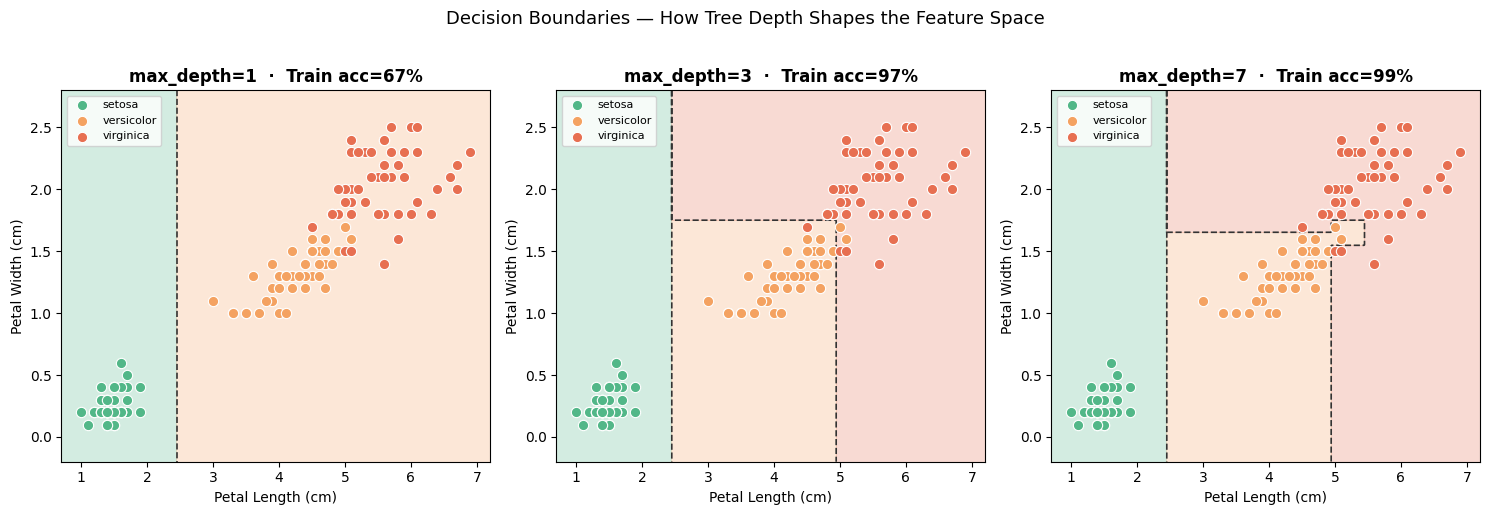

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Load data — use only 2 features for a 2D plot
iris = load_iris()
X = iris.data[:, [2, 3]]   # petal length, petal width
y = iris.target
class_names = iris.target_names
colors = ["#52b788", "#f4a261", "#e76f51"]

# Train three trees at different depths to show the effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
depths = [1, 3, 7]

for ax, depth in zip(axes, depths):

    # Train model
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X, y)

    # Create a dense mesh of points covering the feature space
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # Predict the class for every point in the mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the colored background regions (decision regions)
    for i, color in enumerate(colors):
        ax.contourf(xx, yy, Z == i,
                    levels=[0.5, 1.5], colors=[color], alpha=0.25)

    # Plot decision boundaries as lines
    ax.contour(xx, yy, Z, levels=[0.5, 1.5],
               colors="#333", linewidths=1.2, linestyles="--")

    # Plot the actual training data points
    for i, (color, name) in enumerate(zip(colors, class_names)):
        mask = y == i
        ax.scatter(X[mask, 0], X[mask, 1],
                   color=color, edgecolor="white", s=55,
                   linewidth=0.8, label=name, zorder=3)

    accuracy = clf.score(X, y)
    ax.set_title(f"max_depth={depth}  ·  Train acc={accuracy:.0%}",
                fontsize=12, fontweight="bold")
    ax.set_xlabel("Petal Length (cm)")
    ax.set_ylabel("Petal Width (cm)")
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle(
    "Decision Boundaries — How Tree Depth Shapes the Feature Space",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()